<a href="https://colab.research.google.com/github/smlicciardello-svg/MPM_200_Licciardello/blob/main/Code/MPM200_Session5_HW_SLicciardello.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MPM 200: Assignment 4

### Due 29th October 2025 9AM

* For all questions, you must show your work. This will enable us to understand your thought process, give partial credit, and prevent crude cheating.
* Please make sure that you are not simply copying each other's code, but rather striving to understand each other's work and learn from it
* Additionally, please provide the R code at the end of your solution and include R commands along with R outputs. This will help to describe your solutions more clearly.

# Section 0: R

**Q0: install package "beepr" from CRAN and use *beep()* function to make "MARIO" sound.**

Make sure you have the following packages installed.
1. Tidyverse
2. dplyr
3. ggplot2
4. sjPlot

In [1]:
#install packages
install.packages('beepr')
install.packages('tidyverse')
install.packages('dplyr')
install.packages('ggplot2')
install.packages('sjPlot')

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘audio’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘effectsize’, ‘bayestestR’, ‘datawizard’, ‘ggeffects’, ‘insight’, ‘parameters’, ‘performance’, ‘sjlabelled’, ‘sjmisc’, ‘sjstats’




In [2]:
#libraries
library(beepr)
library(tidyverse)
library(dplyr)
library(ggplot2)
library(sjPlot)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘sjPlot’


The following object is masked from ‘package:ggplot2’:

    set_theme




## Will the hummers survive?

#### As a wildlife veterinarian, you are interested in understanding the trends in hummingbird survival in California. To achieve this, you collaborate with several regional rehabilitation centers and develop a dataset of hummingbird rehabilitation cases, based on records maintained by these centers.


#### The data recorded wasthe  following:

Disposition_binary: Died or Released  
Place: Rehabilitation center  
F_Aid: First aid provided  
Species_e: Hummingbird species: ANHU == Anna's Hummingbirds, NonSselasphorus: non-orange hummingbirds that are not identified till species level, Selasphorus: Hummingbirds that are from Selasphorus genus but not identified until species level, BCHU: Black-chinned hummingbirds  
Sex_e:  
Age_e:  
Brought_in_after: Number of days it was with the rescuer before it came to a  rehabilitation center  
season: season when it was admitted  
r: reason for admission  
Green_Orange: species classification: Green or Orange bird  
ID: unique ID given to the  individual bird


### Your aim is to identify factors that affect the survival or successful release of hummingbirds once they are admitted to the rehabilitation center. You are expected to do the following:
1. Tabulate and plot the distribution of your outcome variable
2. Identify covariates that you think (based on your general understanding) and explore individual covariates
3. Plot/tabulate individual covariates with your outcome
4. Run univariate generalized linear models
5. Run backward elimination to find the best-fitting model
6. Run forward addition to finding the best fitting model

# Section 1
### Reading the data
Here, you will read the **Hummingbird_data.csv** file dataset and create a random sample of it. You will use this random sample of the dataset to complete the rest of the exercise.


**Q1. read the Hummingbird_data.csv file in R**   
2 points

In [4]:
#read the csv file and
data  = read.csv('/content/Hummingbird_data.csv')

In [ ]:
colnames(data)

**Q2. How many rows and columns are in the datafame**  
1 point

In [ ]:
nrow(data)
#6908

In [ ]:
ncol(data)
#12

### Checking the Structure of Each Column and Identifying Data Types
* Use the `str()` function to view the structure of the dataframe.  
*
Use the` sapply(`) function with class() to identify the data types of each column
*
Discuss any observations or potential issues with the data types.

In [ ]:
str(data)


In [ ]:
# Identify data types of each column
data_types = sapply(data, class)
print(data_types)
#The "Admitted" and "ID" variables are all classified as characters when they should all be numerical variables.

Next step is to create a random subset of the given data.   
Use the given code to create the subset data.

In [5]:
library(dplyr)
model_data = sample_n(data, 5000)

**Use *model_data* dataframe to answer remainder questions of the assingment.**

**Q3: How many rows and columns are present in your data frame currently?  
1 Point**

In [6]:
#there are 5000 rows and 12 columns
nrow(model_data)
ncol(model_data)

[1] 5000

[1] 12

**Q4: How many columns are categorical variables, and how many are continuous variables in the dataset?  
2 Points**

In [7]:
# 11 columns are categorical and 1 column is continuous.
data_types = sapply(model_data, class)
print(data_types)

          Admitted Disposition_binary              Place              F_Aid 
       "character"        "character"        "character"        "character" 
         Species_e              Sex_e              Age_e   Brought_in_after 
       "character"        "character"        "character"          "integer" 
            season                  r       Green_Orange                 ID 
       "character"        "character"        "character"        "character" 


**Q5: Submit your model_data file along with your submission.  
Save it as "Hummingbird_data_YOURNAME.csv" and submit it    
2 Points**

In [8]:
write.csv(model_data, "Hummingbird_data_Savannah_Licciardello.csv")

In [9]:
library(ggplot2)

# Section 2
## Rehabilitation Center and number of hummingbirds
Lets see how we can explore how many birds were admitted to each rehabilitation center (represented by column Place).  
We will use functions from` dply`r to generate summary tables and plot them using` GGplot`2

In [10]:
model_data%>%
group_by(Place)%>%
summarise(count = n_distinct(ID))

Place,count
<chr>,<int>
Lindsey,4136
Santa Barbara,65
malibu,799


In [11]:
rehab = model_data  %>%
group_by(Place)%>%
summarise(count = n_distinct(ID))

In [12]:
p = ggplot(rehab, aes(x = Place, y = count)) +
geom_bar(stat="identity", color = 'steelblue', fill = 'steelblue')+
xlab('Rehabilitation center')+ ylab('number of hummingbirds')+
labs(title = "Number of rescued hummingbirds")

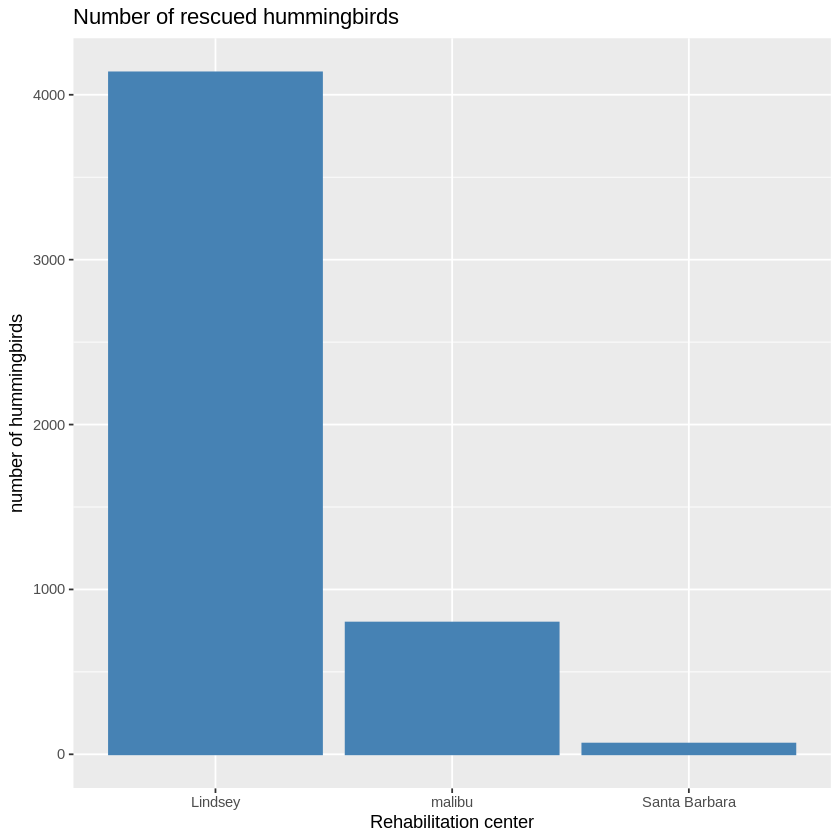

In [13]:
p

**Q6: Please save this plot to a PDF file and submit it along with your assignment. Ensure that the size of the plot is 4 inches wide and 3 inches tall.  
Point: 2**  

In [14]:
ggsave("/content/Rescued_by_location.pdf", width=4, height=3)

**Q7: Please explain the code above in words, including what each line of R code is doing, starting from the code that creates the "Rehab" object until the plot.  
Points: 2**  

In [15]:
#the model_data is the dataframe we are using
#the %>% is a pipeline, stringing the different elements together
#the group_by(Place) groups the rows by the variable "place"
#summarise(count = n_distinct(ID))tells R to summarise the data by counting each group by number of distinct ID in each category of "Place"
#rehab= saves the pipeline to the name "rehab"
#p = ggplot(rehab, aes(x = Place, y = count)) + creates a plot named "p" that uses the data generated in "rehab", with the "place" variable on the x-axis and the count generated in "rehab" on the y-axis
#geom_bar(stat="identity", color = 'steelblue', fill = 'steelblue')+ makes the graph a bar graph, using the stat "identity" and makes the graph the color steel blue
#xlab('Rehabilitation center')+ ylab('number of hummingbirds')+ labels the y and x axis
#labs(title = "Number of rescued hummingbirds") titles the graph
#ggsave("/content/Rescued_by_location.pdf", width=4, height=3) saves the graph to the content folder as a pdf with a width of 4 and a height of 3

# Section 3

## Key variables that affect the survival of hummingbirds  

#### Do the following steps
1. List 5 covariates from data columns that you think might affect the survival.   
2. For each variable, create a table showing the number of birds that survived and died for each subcategory for the covariate.  
3. To do that, create a table first with COVARIATE, Disposition_binary, and unique IDs
4. Then use that data frame to generate bar plots and use  `facet_grid` function in `GGPlot`

**Q8: What is your observation based on those tables and plots? Do you think all those are associated with the final disposition of hummingbirds? Any suggestions for statistically testing them?  
Points: 5**

First aid given and sex do not seem to be associated with final disposition. Age and season do seem to be associated with final disposition. Younger hummingbirds are more likely to be released than older hummingbirds, likely due to younger hummingbirds coming in as otherwise healthy orphans while older hummingbirds come in sick or injured. Season also seems to be associated with disposition, as a smaller porpotion of hummingbirds are released in fall compared to summer. While binary sex does not seem to be associated with disposition, the unknown category has greater releases than deaths. This is likely due to the unknown category consistenting of mostly juveniles while the male and female categories are mostly adults. Although not directly associated with disposition, there are far more females brought in than males, which could be investigated. There are clear seasonal trends in intakes, with the most in Spring, followed by Summer, with the least in fall. This may be due to the seasonality of breeding. You can statistically test these by comparing the different groups using two-sample t-test for a difference in means between the groups.

In [16]:
#Covariates=F_Aid, Age_e, sex_e, season, r,
df_f_aid = model_data  %>%
group_by(F_Aid, Disposition_binary)%>%
summarise(count = n_distinct(ID))

`summarise()` has grouped output by 'F_Aid'. You can override using the
`.groups` argument.


In [17]:
df_f_aid

F_Aid,Disposition_binary,count
<chr>,<chr>,<int>
No,Died,2074
No,Released,1203
Yes,Died,1113
Yes,Released,610


In [18]:
p_first_aid = ggplot(df_f_aid, aes(x = F_Aid, y = count, fill= Disposition_binary)) +
geom_bar(stat="identity", position= "dodge")+
xlab('First aid administered')+ ylab('number of hummingbirds')+
labs(title = "Survival Outcome by first aid administration")

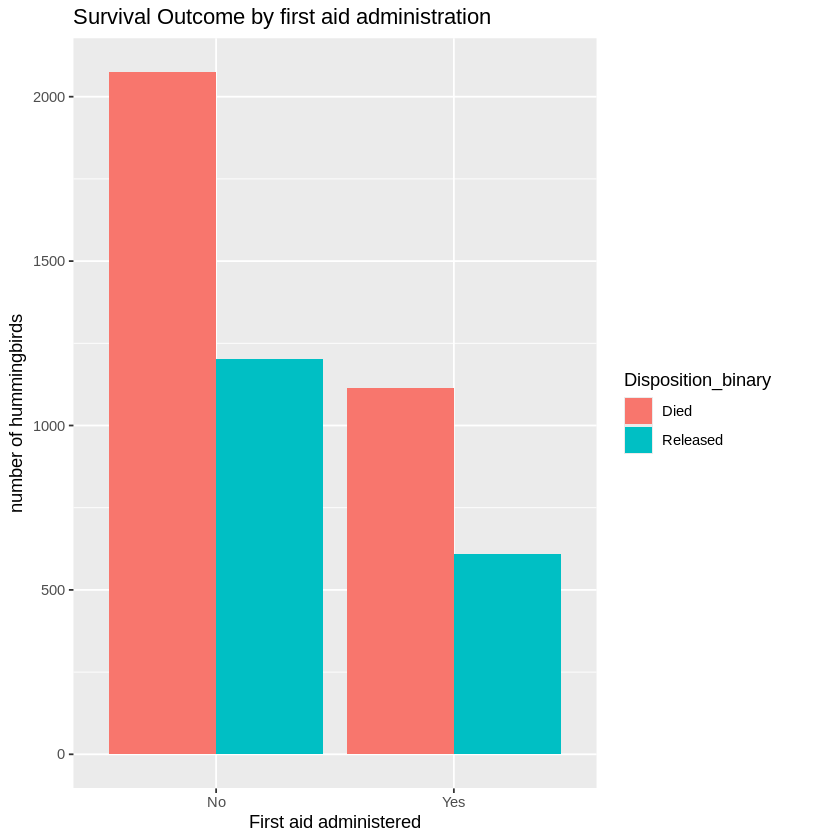

In [19]:
p_first_aid

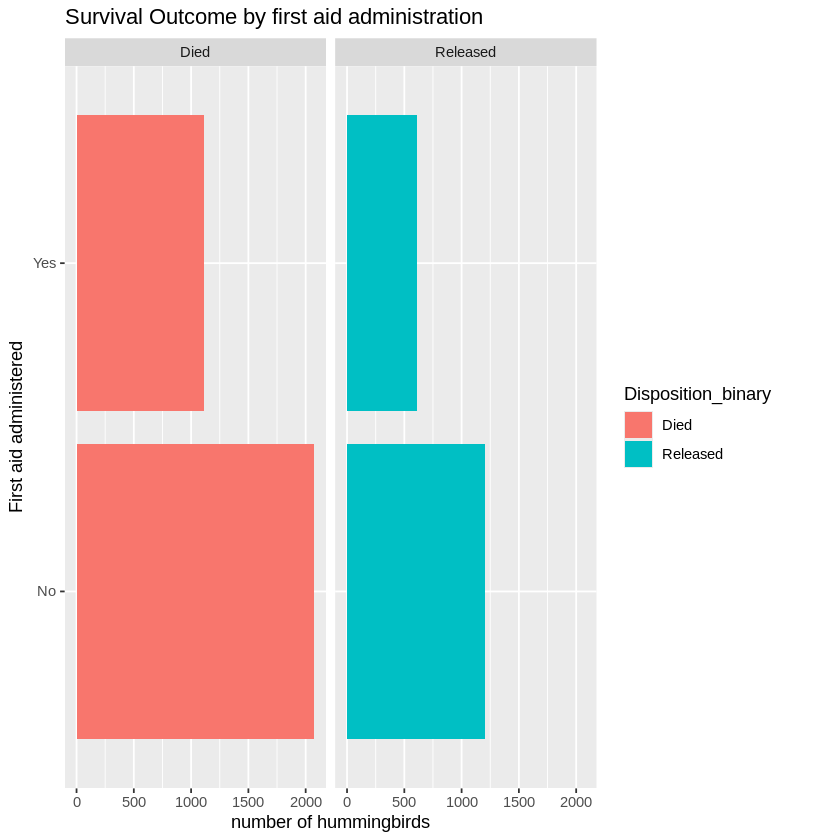

In [20]:
p_first_aid + facet_grid(.~Disposition_binary) + coord_flip()

In [21]:
df_age = model_data  %>%
group_by(Age_e, Disposition_binary)%>%
summarise(count = n_distinct(ID))
df_age

`summarise()` has grouped output by 'Age_e'. You can override using the
`.groups` argument.


Age_e,Disposition_binary,count
<chr>,<chr>,<int>
Nestling,Died,404
Nestling,Released,758
adult-like,Died,2783
adult-like,Released,1055


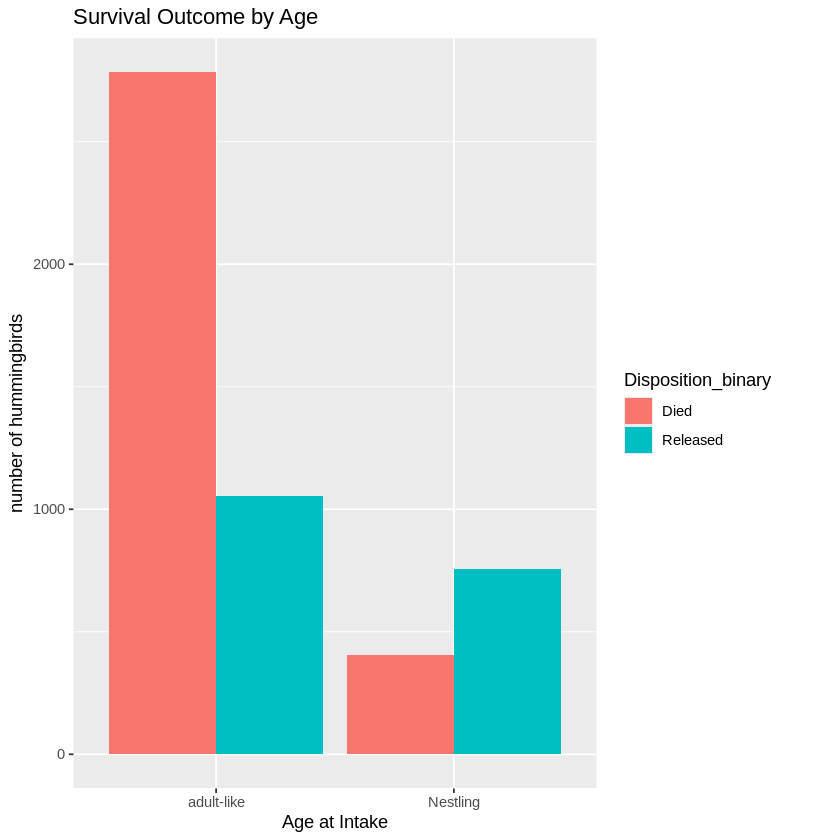

In [22]:
p_age = ggplot(df_age, aes(x = Age_e, y = count, fill= Disposition_binary)) +
geom_bar(stat="identity", position= "dodge")+
xlab('Age at Intake')+ ylab('number of hummingbirds')+
labs(title = "Survival Outcome by Age")
p_age

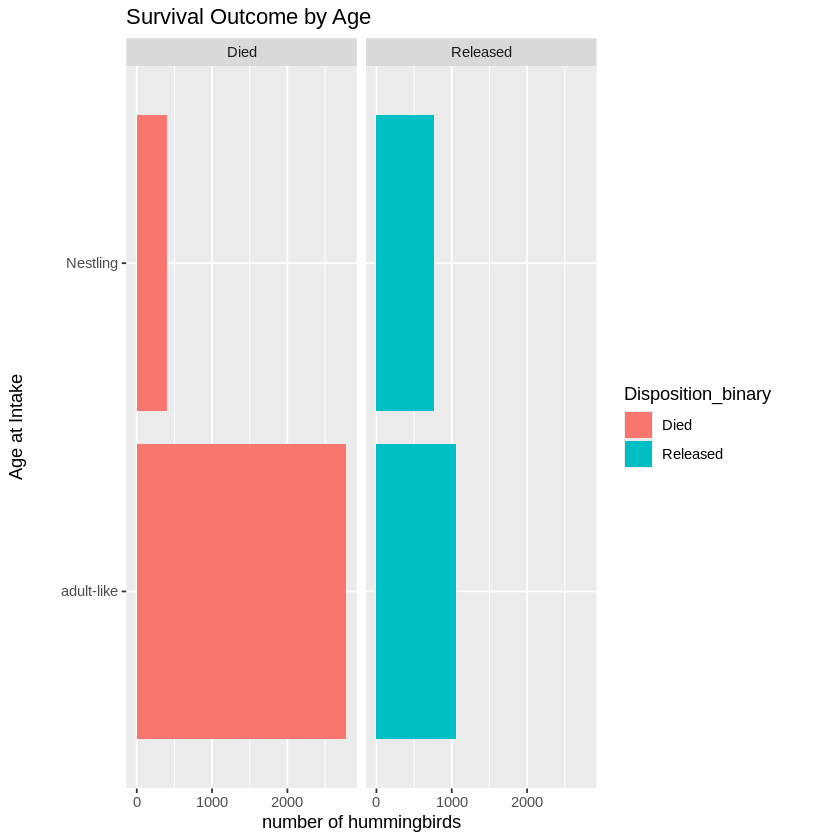

In [23]:
p_age + facet_grid(.~Disposition_binary) + coord_flip()

In [24]:
df_sex = model_data  %>%
group_by(Sex_e, Disposition_binary)%>%
summarise(count = n_distinct(ID))
df_sex

`summarise()` has grouped output by 'Sex_e'. You can override using the
`.groups` argument.


Sex_e,Disposition_binary,count
<chr>,<chr>,<int>
Female-like,Died,2335
Female-like,Released,936
Male,Died,438
Male,Released,119
unknown,Died,414
unknown,Released,758


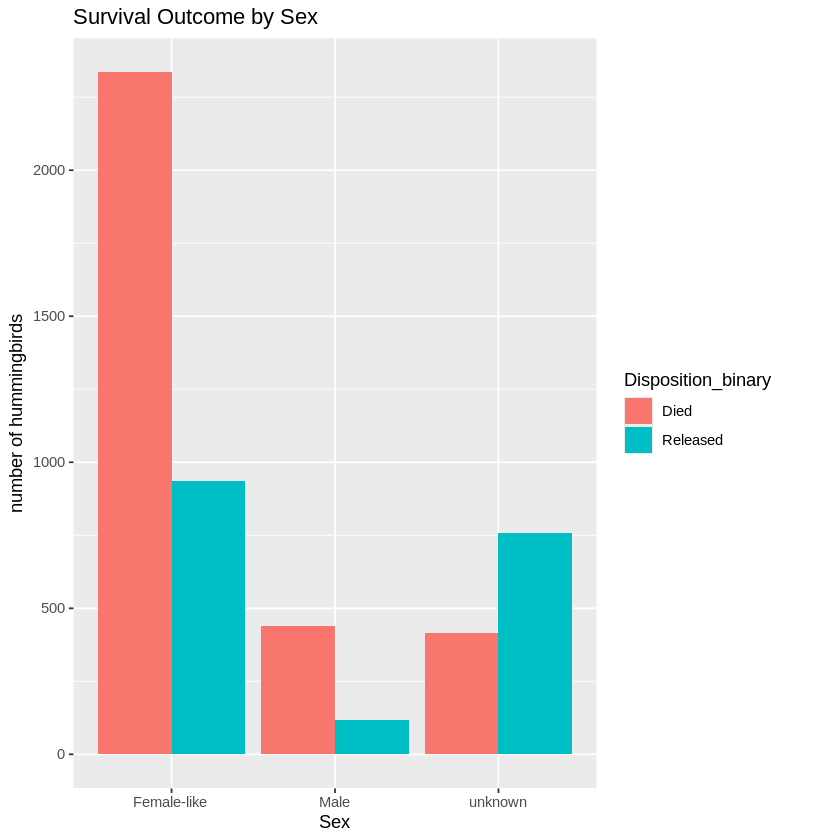

In [25]:
p_sex = ggplot(df_sex, aes(x = Sex_e, y = count, fill= Disposition_binary)) +
geom_bar(stat="identity", position= "dodge")+
xlab('Sex')+ ylab('number of hummingbirds')+
labs(title = "Survival Outcome by Sex")
p_sex

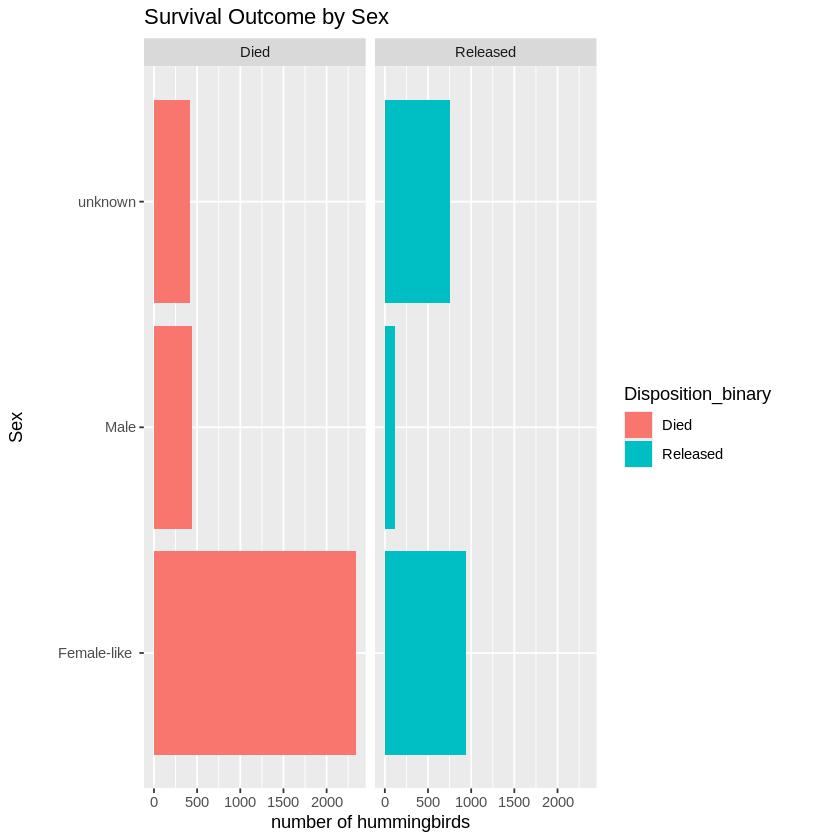

In [26]:
p_sex + facet_grid(.~Disposition_binary) + coord_flip()

In [27]:
df_season = model_data  %>%
group_by(season, Disposition_binary)%>%
summarise(count = n_distinct(ID))
df_season

`summarise()` has grouped output by 'season'. You can override using the
`.groups` argument.


season,Disposition_binary,count
<chr>,<chr>,<int>
Fall,Died,365
Fall,Released,60
Spring,Died,1329
Spring,Released,983
Summer,Died,936
Summer,Released,584
Winter,Died,557
Winter,Released,186


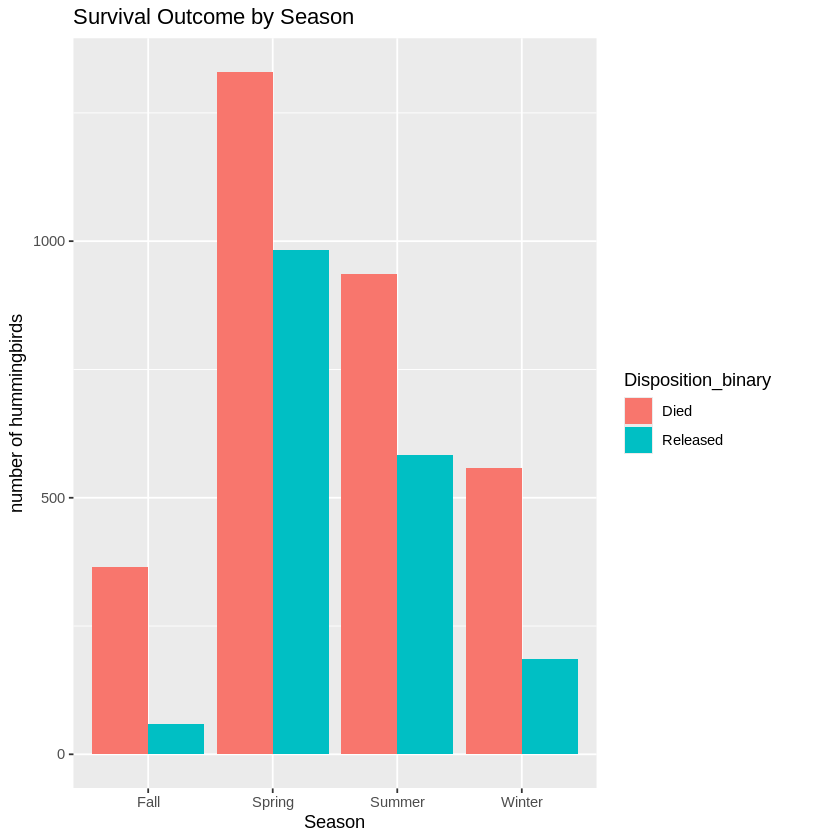

In [28]:
p_season = ggplot(df_season, aes(x = season, y = count, fill= Disposition_binary)) +
geom_bar(stat="identity", position= "dodge")+
xlab('Season')+ ylab('number of hummingbirds')+
labs(title = "Survival Outcome by Season")
p_season

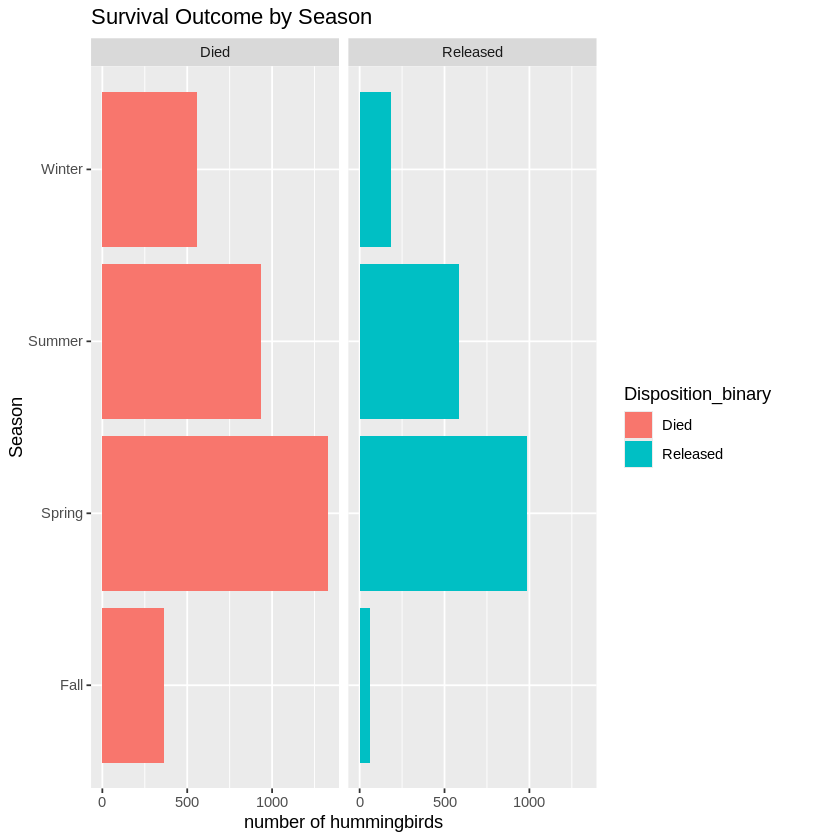

In [29]:
p_season + facet_grid(.~Disposition_binary) + coord_flip()

In [30]:
df_reason = model_data  %>%
group_by(r, Disposition_binary)%>%
summarise(count = n_distinct(ID))
df_reason

`summarise()` has grouped output by 'r'. You can override using the `.groups`
argument.


r,Disposition_binary,count
<chr>,<chr>,<int>
caught by domestic animal,Died,459
caught by domestic animal,Released,175
found inside,Died,115
found inside,Released,47
found on the ground,Died,1384
found on the ground,Released,721
nest-related,Died,268
nest-related,Released,416
suspect torpor-like state,Died,94


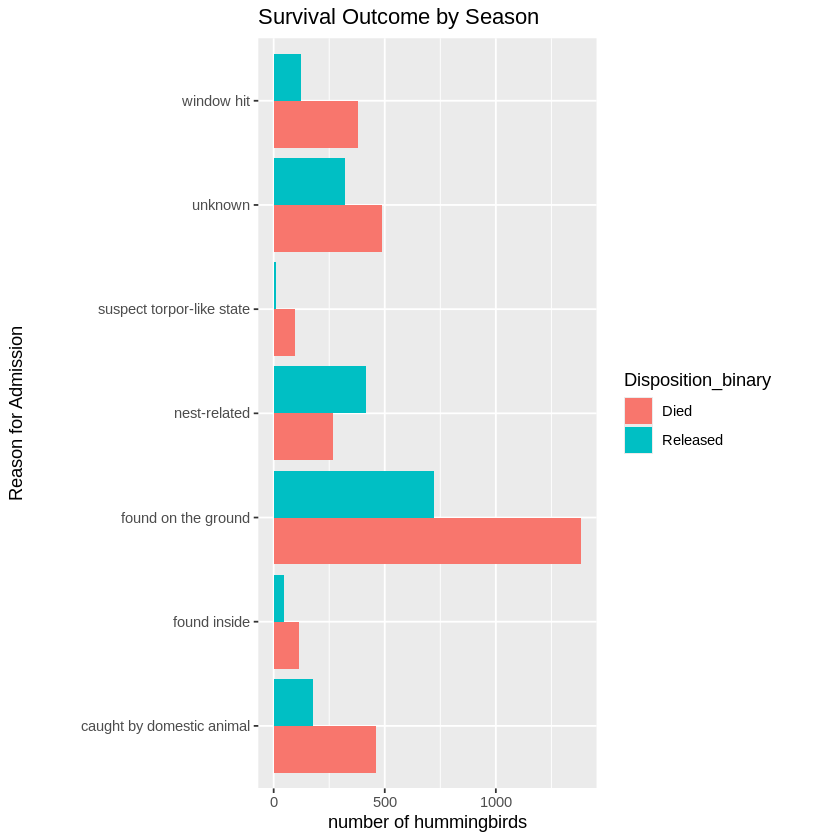

In [31]:
p_reason = ggplot(df_reason, aes(x = r, y = count, fill= Disposition_binary)) +
geom_bar(stat="identity", position= "dodge")+
xlab('Reason for Admission')+ ylab('number of hummingbirds')+
labs(title = "Survival Outcome by Season")+
coord_flip()
p_reason

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


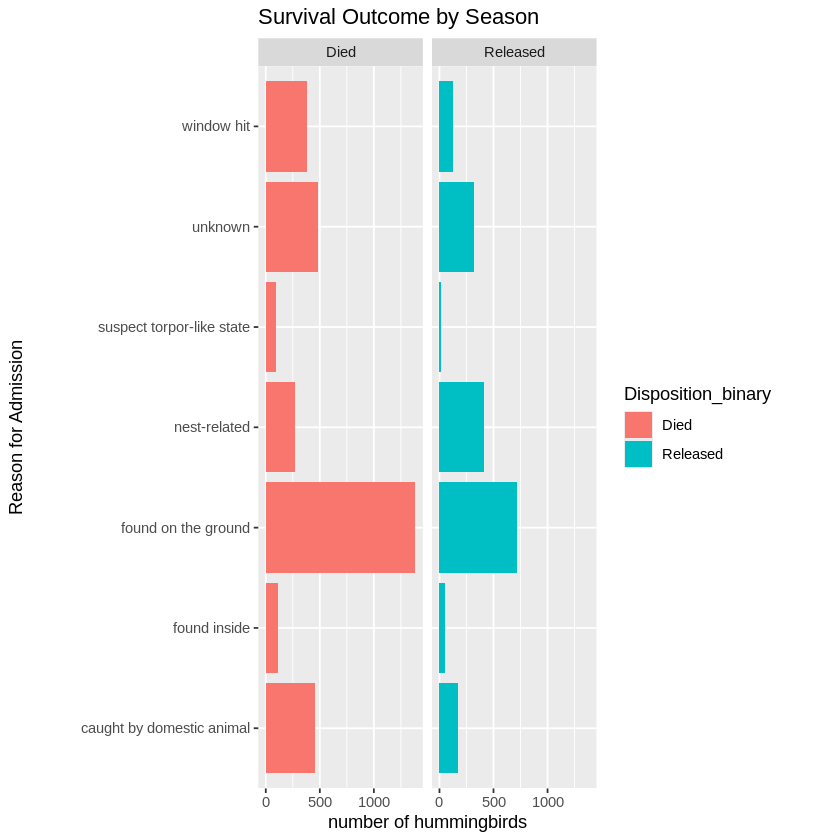

In [32]:
p_reason + facet_grid(.~Disposition_binary) + coord_flip()

## Calculating Proportions

#### Q10: Calculate the proportion of hummingbirds that were released versus those that died for each rehabilitation center.
* Use the `model_data` dataframe to calculate these proportions.
*
Create a table showing the proportions for each rehabilitation center (denoted by column `Place`)   .*
Plot a bar chart to visualize these proportions.

`summarise()` has grouped output by 'Place'. You can override using the
`.groups` argument.


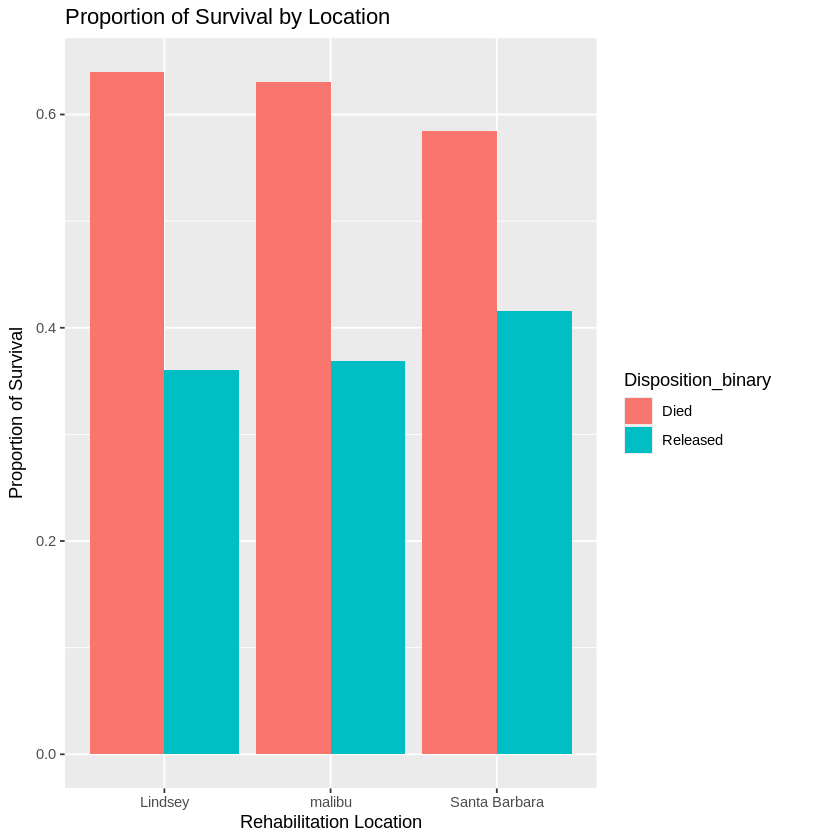

In [33]:
# Calculate proportions
proportions = model_data %>%
  group_by(Place, Disposition_binary) %>%
  summarise(count=n_distinct(ID)) %>%
  mutate(proportion = count / sum(count))

# Plot the proportions
ggplot(proportions, aes(x = Place, y = proportion, fill = Disposition_binary)) +
  geom_bar(stat = "identity", position = "dodge") +
  xlab('Rehabilitation Location') +
  ylab('Proportion of Survival') +
  labs(title = "Proportion of Survival by Location")

### Merging Species into Groups/Families  
#### Q11: Merge the Species_e column into broader categories (e.g., Anna's Hummingbirds, Selasphorus genus, Non-selasphorus, Black-chinned Hummingbirds).
* Anna's Hummingbird, Black-chinned Hummingbird and "non-selasphorous' hummingbirds need to be classified as Non-selasphorus
* All Selasphorus species should be classified as `Selasphorus`
* Create a new column `Species_group` that categorizes the species into these broader groups.
* Tabulate and plot the distribution of hummingbirds by these new species groups.
* Analyze how the survival rates differ across these species groups.

Survival is greater for selasphorus species than non-selasphorus species.

`summarise()` has grouped output by 'Species_group'. You can override using the
`.groups` argument.


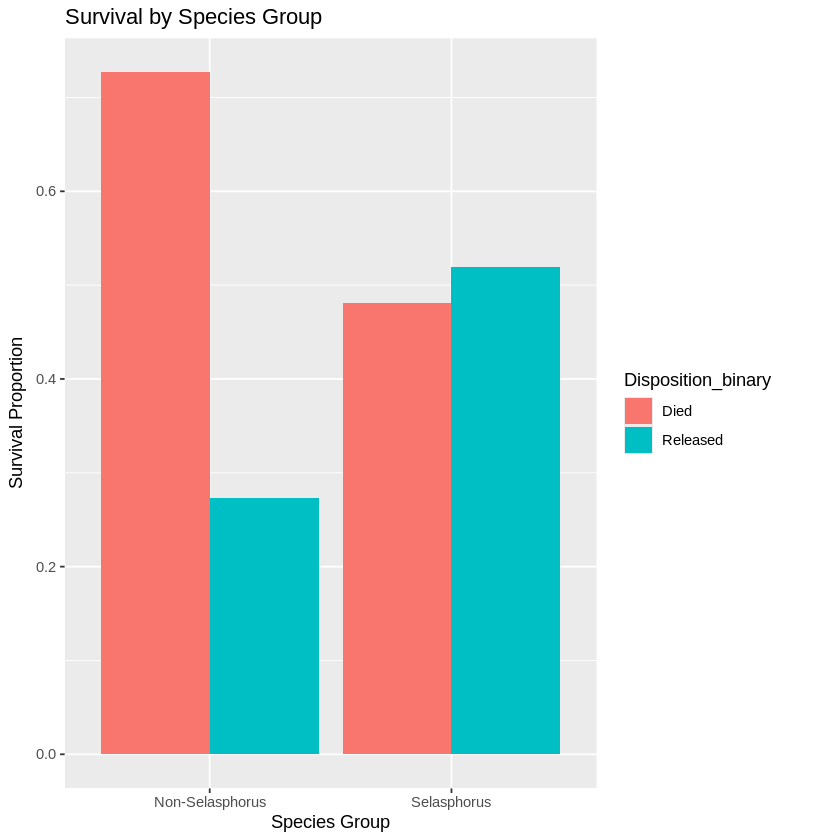

In [34]:
## Hint: think about the logic. How would you quickly classify these species into multiple groups using ifelse statement?

model_data$Species_group = ifelse(model_data$Species_e %in% c('ANHU','BCHU','NonSselasphorus'),
                                  'Non-Selasphorus', 'Selasphorus')

# Tabulate and plot the distribution
species_distribution = model_data %>%
  group_by(Species_group, Disposition_binary) %>%
  summarise(count=n_distinct(ID)) %>%
  mutate(proportion = count / sum(count))

ggplot(species_distribution, aes(x = Species_group, y = proportion, fill = Disposition_binary)) +
  geom_bar(stat = "identity", position = "dodge") +
  xlab('Species Group') +
  ylab('Survival Proportion') +
  labs(title = "Survival by Species Group")

### Q12 Analyze the Trend of Hummingbird Admissions Over Time
* Convert the `Admitted` column to a date format.
*
Summarize the trend of hummingbird admissions over time
*
Plot the trend using `ggplot2`.

In [35]:
model_data$Admitted_date = as.Date(model_data$Admitted, format = "%m/%d/%Y")
# we assign the formatting to the data set before the $ and the column after the $
# as.Date is the function for formatting dates
# we format the column Admitted of the data set model_data
# format = is how we define exactly what format we want, in this case month/day/year

Q12a Please explain the argument `format` in code above

This creates a new column "admitted_date" that is added to "model_data". The as.Date reformats the column "Admitted" into month/date/year.

The next step is to summarize the number of birds seen in each month and similarly in each year.

In [36]:
admissions_by_month = model_data %>%
  mutate(Admitted_month = format(Admitted_date, "%Y-%m")) %>%
  group_by(Admitted_month) %>%
  summarise(count=n_distinct(ID))

admissions_by_year = model_data %>%
  mutate(Admitted_year = format(Admitted_date, "%Y")) %>%
  group_by(Admitted_year) %>%
  summarise(count=n_distinct(ID))

Finally, we can use `ggplot` to plot these timelines.

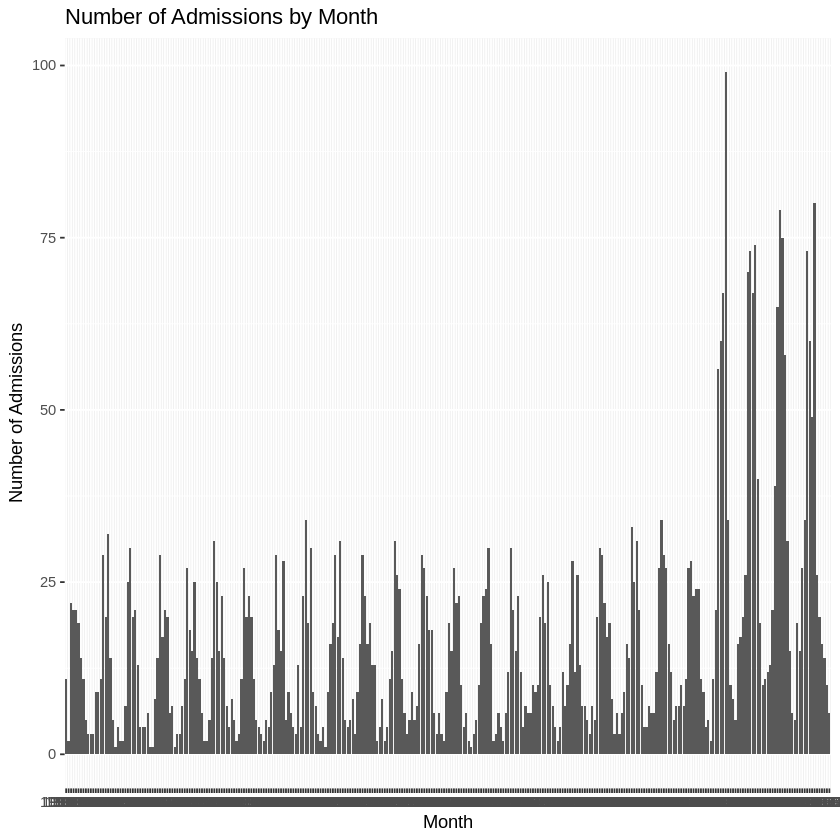

In [37]:
# Plot admissions by month
p_month = ggplot(admissions_by_month, aes(x = Admitted_month, y = count)) +
  geom_bar(stat = "identity") +
  xlab('Month') +
  ylab('Number of Admissions') +
  labs(title="Number of Admissions by Month")
p_month

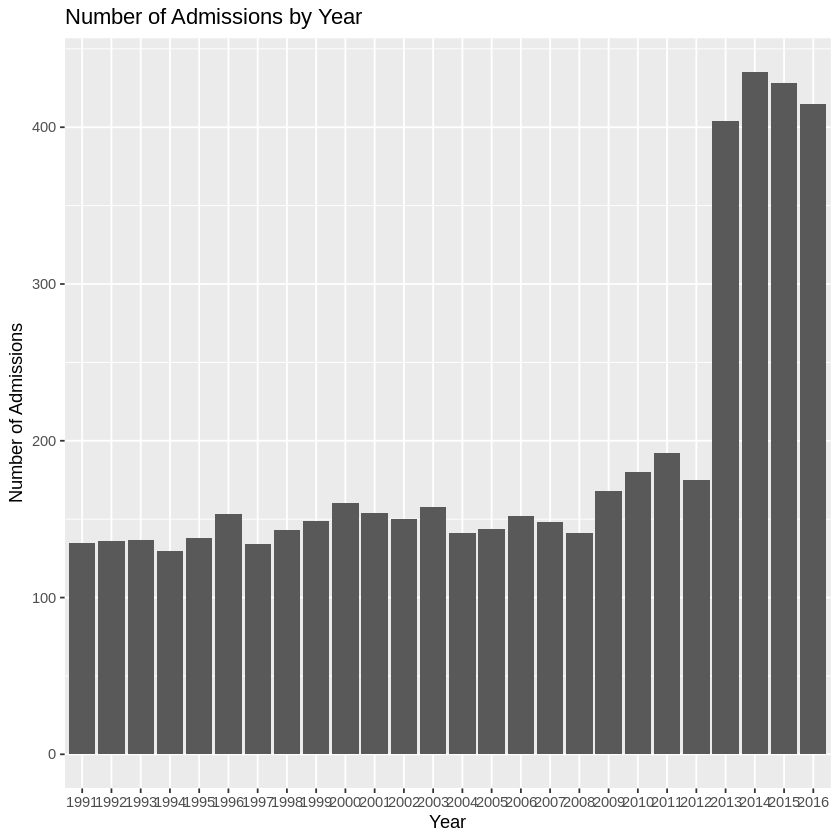

In [38]:
## Plot similar timeline for Yearly admissions of Hummingbirds
p_year = ggplot(admissions_by_year, aes(x = Admitted_year, y = count)) +
  geom_bar(stat = "identity") +
  xlab('Year') +
  ylab('Number of Admissions') +
  labs(title="Number of Admissions by Year")
p_year

GitHub Assignment New Plot


`summarise()` has grouped output by 'Admitted_month'. You can override using
the `.groups` argument.


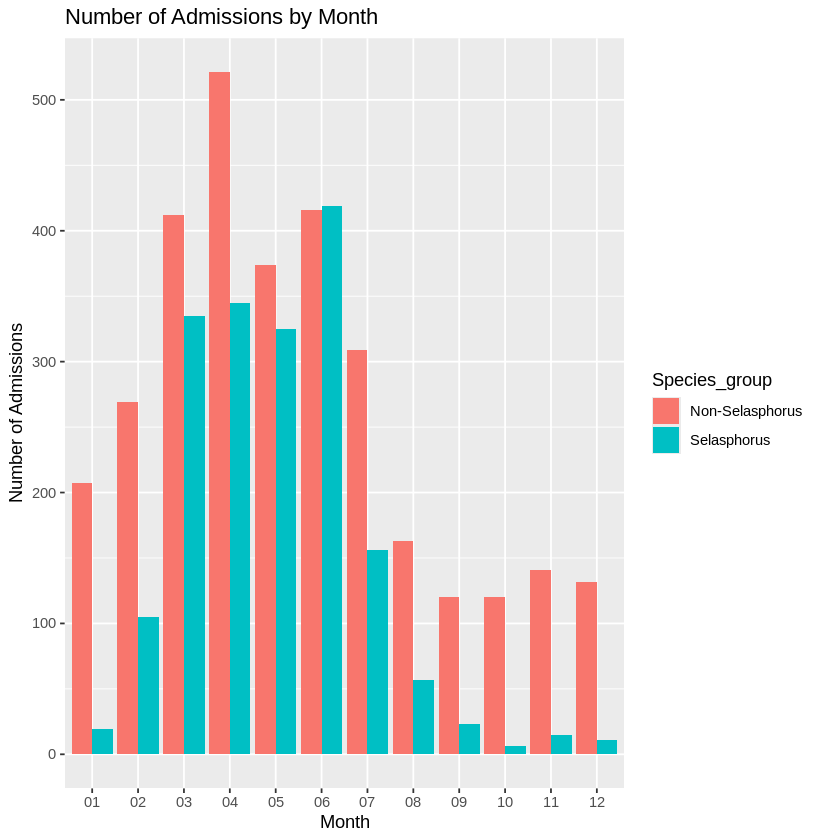

In [44]:
admissions_by_month_new = model_data %>%
  mutate(Admitted_month = format(Admitted_date, "%m")) %>%
  group_by(Admitted_month, Species_group) %>%
  summarise(count=n_distinct(ID))

p_month_new = ggplot(admissions_by_month_new, aes(x = Admitted_month, y = count, fill=Species_group)) +
  geom_bar(stat = "identity", position="dodge") +
  xlab('Month') +
  ylab('Number of Admissions') +
  labs(title="Number of Admissions by Month")
p_month_new

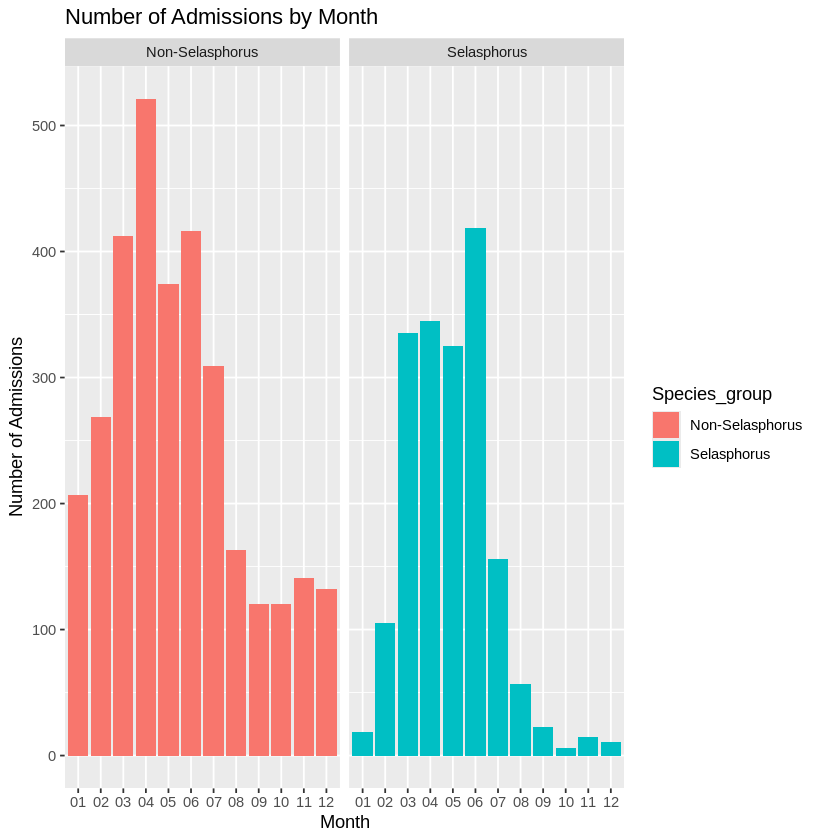

In [45]:
p_month_new + facet_grid(.~Species_group)